In [25]:
import os
import numpy as np
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from torch.utils.data import DataLoader, random_split
import torch.optim as optim
import time
import random
import pandas as pd
import os
from PIL import Image

In [26]:
# Some Data Augmntation
transform_for_resNet = transforms.Compose ([transforms.RandomHorizontalFlip(p=0.5), transforms.RandomRotation(degrees=15), transforms.Resize((224, 224)), transforms.ToTensor(), transforms.Normalize(mean = [0.485, 0.456, 0.406], std = [0.229, 0.224, 0.225])])

# Validation Pipeline only resize and normalize
validation_transforms = transforms.Compose ([transforms.Resize((224, 224)), transforms.ToTensor(), transforms.Normalize(mean = [0.485, 0.456, 0.406], std = [0.229, 0.224, 0.225])])

# Pointing pytorch to training folder
train_dir = 'train/'
training_dataset = datasets.ImageFolder(root=train_dir, transform=transform_for_resNet)

# Checking num images and classes loaded as a cross check
print(f" Number of imgages loaded: {len(training_dataset)}")
print(f" Number of classes: {len(training_dataset.classes)}")

# Data grouped into batches of 32
train_loader = DataLoader(training_dataset, batch_size = 32, shuffle = True)
images, labels = next(iter(train_loader))

print(f"Batch shape: {images.shape}")

 Number of imgages loaded: 1079
 Number of classes: 100
Batch shape: torch.Size([32, 3, 224, 224])


In [28]:
device = torch.device("mps")

# Loading up te ResNet model 
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# Locking down the entire network (saving pre-trained weights)
for x in model.parameters():
    x.requires_grad = False

# Partially unfreezing layer 3
for y in model.layer3.parameters():
    y.requires_grad = True

# Partially unfreezing layer 4
for y in model.layer4.parameters():
    y.requires_grad = True

# Removing the default classifier head 
num_features =  model.fc.in_features

# Adding new classifier head
model.fc = nn.Sequential(
    # randomized dropout of 50% of neurons during learning
    nn.Dropout(p=0.5), 
    # Features down to 100 specific classes
    nn.Linear(num_features, 100)
)

# model to GPU
model = model.to(device)
 
print("Completed")


Completed


In [29]:
# Splitting data into 80% training and 20% validation
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
train_size = int(0.8 * len(training_dataset))
validation_size = len(training_dataset) - train_size
training_data, validation_data = random_split(training_dataset, [train_size, validation_size])

# DataLoaders setup
training_loader = DataLoader(training_data, batch_size=32, shuffle=True)
validation_loader = DataLoader(validation_data, batch_size=32, shuffle=False)

# Setting up for Cross Entropy Loss
criterion = nn.CrossEntropyLoss()

# Making a list of unfrozen parameters by grabbing them from model parameters
unfrozen_parameters = [x for x in model.parameters() if x.requires_grad]

# Learning Rate = 1e-4 and L2 regularization weight decay = (diff incorrect guess) + 0.1 * (square the size of all weights)
optimizer = optim.AdamW(unfrozen_parameters, lr=1e-4, weight_decay=0.1)

# Reducing learning rate by 1/2 after every 5 epochs
decrease_learning_rate = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

# Initialize History Tracker for Slide Deck Graphs
history = {'train_loss': [], 'validation_loss': [], 'training_accuracy': [], 'validation_accuracy': []}

# Set up for early stopping later due to high epoch count
best_validation_accuracy = 0.0

# The Training Loop 
# Increased epochs from 10 to 20 due to Training Accuracy increasing exponentially because of overfitting
epoch_count = 20

print(f"Begin training for {epoch_count} epochs...")
start_time = time.time()

for epoch in range(epoch_count):
    # Begin the training
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    
    # Setting up the tqdm progress bar
    for inputs, labels in tqdm(training_loader, desc=f"Epoch {epoch+1}/{epoch_count} [Train]"):
        inputs, labels = inputs.to(device), labels.to(device)
        
        # Wiping old gradient and incorporation of the new gradient
        optimizer.zero_grad()
        
        # Forward pass
        model_guess = model(inputs)
        
        # Cross entropy caclulating loss
        loss = criterion(model_guess, labels)
        
        # Back propagation
        loss.backward()
        
        # Model altering weights in layer 4
        optimizer.step()
        
        # Extracting total loss
        running_loss += loss.item() * inputs.size(0)
        
        # Saving the value the model gave highest probablity to
        confidence_value, predicted = model_guess.max(1)
        
        #Count of number of images processed thus far
        total += labels.size(0)
        
        # Comparing predictions to actual labels
        # Counting number correct
        correct += predicted.eq(labels).sum().item()
    
    # Calcultating overall training loss and accuracy
    training_loss = running_loss / total
    training_accuracy = 100. * correct / total
    
    # Evaluation of traied model
    
    # Setting up model eval
    model.eval()
    
    validation_loss, correct, total = 0.0, 0, 0
    
    # No Dropout for validation and no updating weights
    with torch.no_grad():
        for inputs, labels in validation_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            # Model guesses on 20% validation data and caculates loss
            model_validation_guess = model(inputs)
            loss = criterion(model_validation_guess, labels)
            
            # Keeping track of loss
            validation_loss += loss.item() * inputs.size(0)
            
            # Grabbing highest probability of predicted
            confidence_value, predicted = model_validation_guess.max(1)
            
            # Calculating number of scores that were correct
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    # Final Validation loss and accuracy calculation
    validation_loss = validation_loss / total
    validation_accuracy = 100. * correct / total
    
    #if validation_accuracy > best_validation_accuracy:
        #best_validation_accuracy = validation_accuracy
        #torch.save(model.state_dict(), 'vaishnavi_cse144_finalmodel.pth')
        
    # Model decides whether to reduce the learning rate by 1/2
    decrease_learning_rate.step()
    current_learning_rate = decrease_learning_rate.get_last_lr()[0]
    
    # Saving values
    history['train_loss'].append(training_loss)
    history['validation_loss'].append(validation_loss)
    history['training_accuracy'].append(training_accuracy)
    history['validation_accuracy'].append(validation_accuracy)
    
    print(f"Epoch {epoch+1} Results - Train Accuracy: {training_accuracy:.2f}% | Validation Accuracy: {validation_accuracy:.2f}% | LR: {current_learning_rate:.6f}")

print(f"\n Training completed in {(time.time() - start_time)/60:.2f} minutes")

# Save the weights
torch.save(model.state_dict(), 'vaishnavi_cse144_finalmodel.pth')
print("Model saved as 'vaishnavi_cse144_finalmodel.pth'")

Begin training for 20 epochs...


Epoch 1/20 [Train]:   0%|          | 0/27 [00:00<?, ?it/s]

Epoch 1 Results - Train Accuracy: 5.45% | Validation Accuracy: 13.89% | LR: 0.000100


Epoch 2/20 [Train]:   0%|          | 0/27 [00:00<?, ?it/s]

Epoch 2 Results - Train Accuracy: 20.39% | Validation Accuracy: 20.83% | LR: 0.000100


...

Epoch 18 Results - Train Accuracy: 97.22% | Validation Accuracy: 60.65% | LR: 0.000013


Epoch 19/20 [Train]:   0%|          | 0/27 [00:00<?, ?it/s]

Epoch 19 Results - Train Accuracy: 97.80% | Validation Accuracy: 58.33% | LR: 0.000013


Epoch 20/20 [Train]:   0%|          | 0/27 [00:00<?, ?it/s]

Epoch 20 Results - Train Accuracy: 97.80% | Validation Accuracy: 61.11% | LR: 0.000006

 Training completed in 9.68 minutes
Model saved as 'vaishnavi_cse144_finalmodel.pth'


In [30]:
device = torch.device("mps")

# Image pipeline for the test data, resize, convert to tensor, and applying ImageNet normalization
validation_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Building the ResNet-50 skeleton
model = models.resnet50(weights=None)

# Chopping off the default classification head and replacing it with our custom one
num_features = model.fc.in_features
model.fc = nn.Sequential(
    # 50% dropout
    nn.Dropout(p=0.5),
    
    # Mapping down to 100 specific classes
    nn.Linear(num_features, 100)
)

# Loasing the trained weights 
model.load_state_dict(torch.load('vaishnavi_cse144_finalmodel.pth', map_location=device))

# Sending model to GPU and locking into evaluation mode (no more training)
model = model.to(device)
model.eval()

# Setting up for lists csv
predictions = []
image_ids = []
test_dir = 'test/'

# Grabbing folder names from training set dict
class_names = training_dataset.classes 

# Turning off gradient tracking
with torch.no_grad():
    # This sorts the images numerically (0.jpg, 1.jpg, 2.jpg... 10.jpg)
    for image_name in tqdm(sorted(os.listdir(test_dir), key=lambda x: int(x.split('.')[0])), desc="Evaluating"):
        if image_name.lower().endswith(('.jpg', '.jpeg', '.png')):
            img_path = os.path.join(test_dir, image_name)
            
            # Locating and opening the image in RGB
            img = Image.open(img_path).convert('RGB')
            img_tensor = validation_transforms(img).unsqueeze(0).to(device)
            
            # model's guess
            model_guess = model(img_tensor)
            
            # Taking the index of the highest probability 
            confidence_value, predicted_index = model_guess.max(1)
            
            # Translating the PyTorch index back to the real Kaggle folder name
            actual_kaggle_label = class_names[predicted_index.item()]
            
            image_ids.append(image_name)
            predictions.append(actual_kaggle_label)

# All results compiled into a Pandas DF
submission_df = pd.DataFrame({
    'ID': image_ids,
    'Label': predictions
})

# Exporting to csv for kaggle submission
submission_df.to_csv('submission.csv', index=False)

Evaluating:   0%|          | 0/1036 [00:00<?, ?it/s]

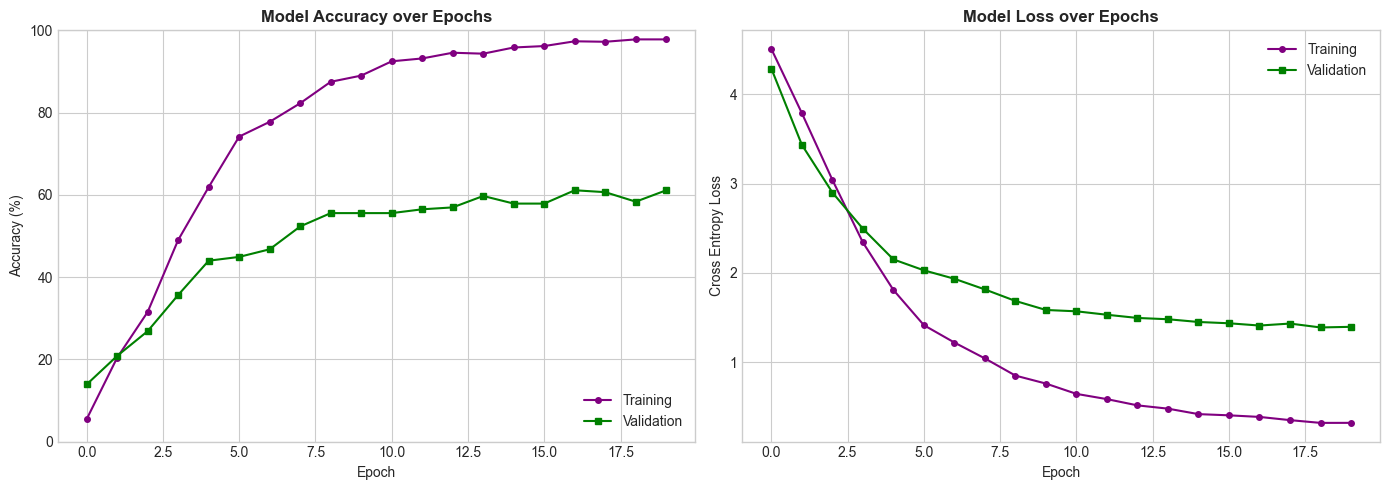

In [31]:
# Plots

# White grid style 
plt.style.use('seaborn-v0_8-whitegrid') 

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Accuracy (Purple for Train, Green for Validation)
ax1.plot(history['training_accuracy'], label='Training', color='purple', marker='o', markersize=4)
ax1.plot(history['validation_accuracy'], label='Validation', color='green', marker='s', markersize=4)
ax1.set_title('Model Accuracy over Epochs', fontsize=12, fontweight='bold')
ax1.set_xlabel('Epoch', fontsize=10)
ax1.set_ylabel('Accuracy (%)', fontsize=10)
ax1.legend(loc='lower right')
ax1.set_ylim([0, 100])

# Plot 2: Loss (Purple for Train, Green for Validation)
ax2.plot(history['train_loss'], label='Training', color='purple', marker='o', markersize=4)
ax2.plot(history['validation_loss'], label='Validation', color='green', marker='s', markersize=4)
ax2.set_title('Model Loss over Epochs', fontsize=12, fontweight='bold')
ax2.set_xlabel('Epoch', fontsize=10)
ax2.set_ylabel('Cross Entropy Loss', fontsize=10)
ax2.legend(loc='upper right')

plt.tight_layout()
# saving figures 
plt.savefig('training_curves_final.png', dpi=300)
plt.show()